In [1]:
%load_ext autoreload
%autoreload 2
import os
import sys
import logging

sys.path.append(os.path.join('..','src'))
logging.basicConfig()

In [2]:
from timeseries_autoencoder import data
data.logger.setLevel(logging.DEBUG)

In [3]:
train_data, train_labels, test_data, test_labels = data.get_ECG5000(keep_original_labels = True)

DEBUG:timeseries_autoencoder.data:creating temp file in ../data/temp/ECG5000
DEBUG:timeseries_autoencoder.data:file ../data/temp/ECG5000/ECG5000.zip already exists
DEBUG:timeseries_autoencoder.data:extracting ../data/temp/ECG5000/ECG5000.zip to ../data/temp/ECG5000
DEBUG:timeseries_autoencoder.data:reading ../data/temp/ECG5000/ECG5000_TRAIN.arff
DEBUG:timeseries_autoencoder.data:reading ../data/temp/ECG5000/ECG5000_TEST.arff


In [4]:
import pandas as pd
df = pd.DataFrame(
    data={'label': train_labels}
)
df.groupby('label').size()

label
1.0    292
2.0    177
3.0     10
4.0     19
5.0      2
dtype: int64

In [5]:
nominal_train_data = train_data[train_labels == 1]
class_2_train_data = train_data[train_labels == 2]
class_3_train_data = train_data[train_labels == 3]
class_4_train_data = train_data[train_labels == 4]
class_5_train_data = train_data[train_labels == 5]
len(nominal_train_data)


292

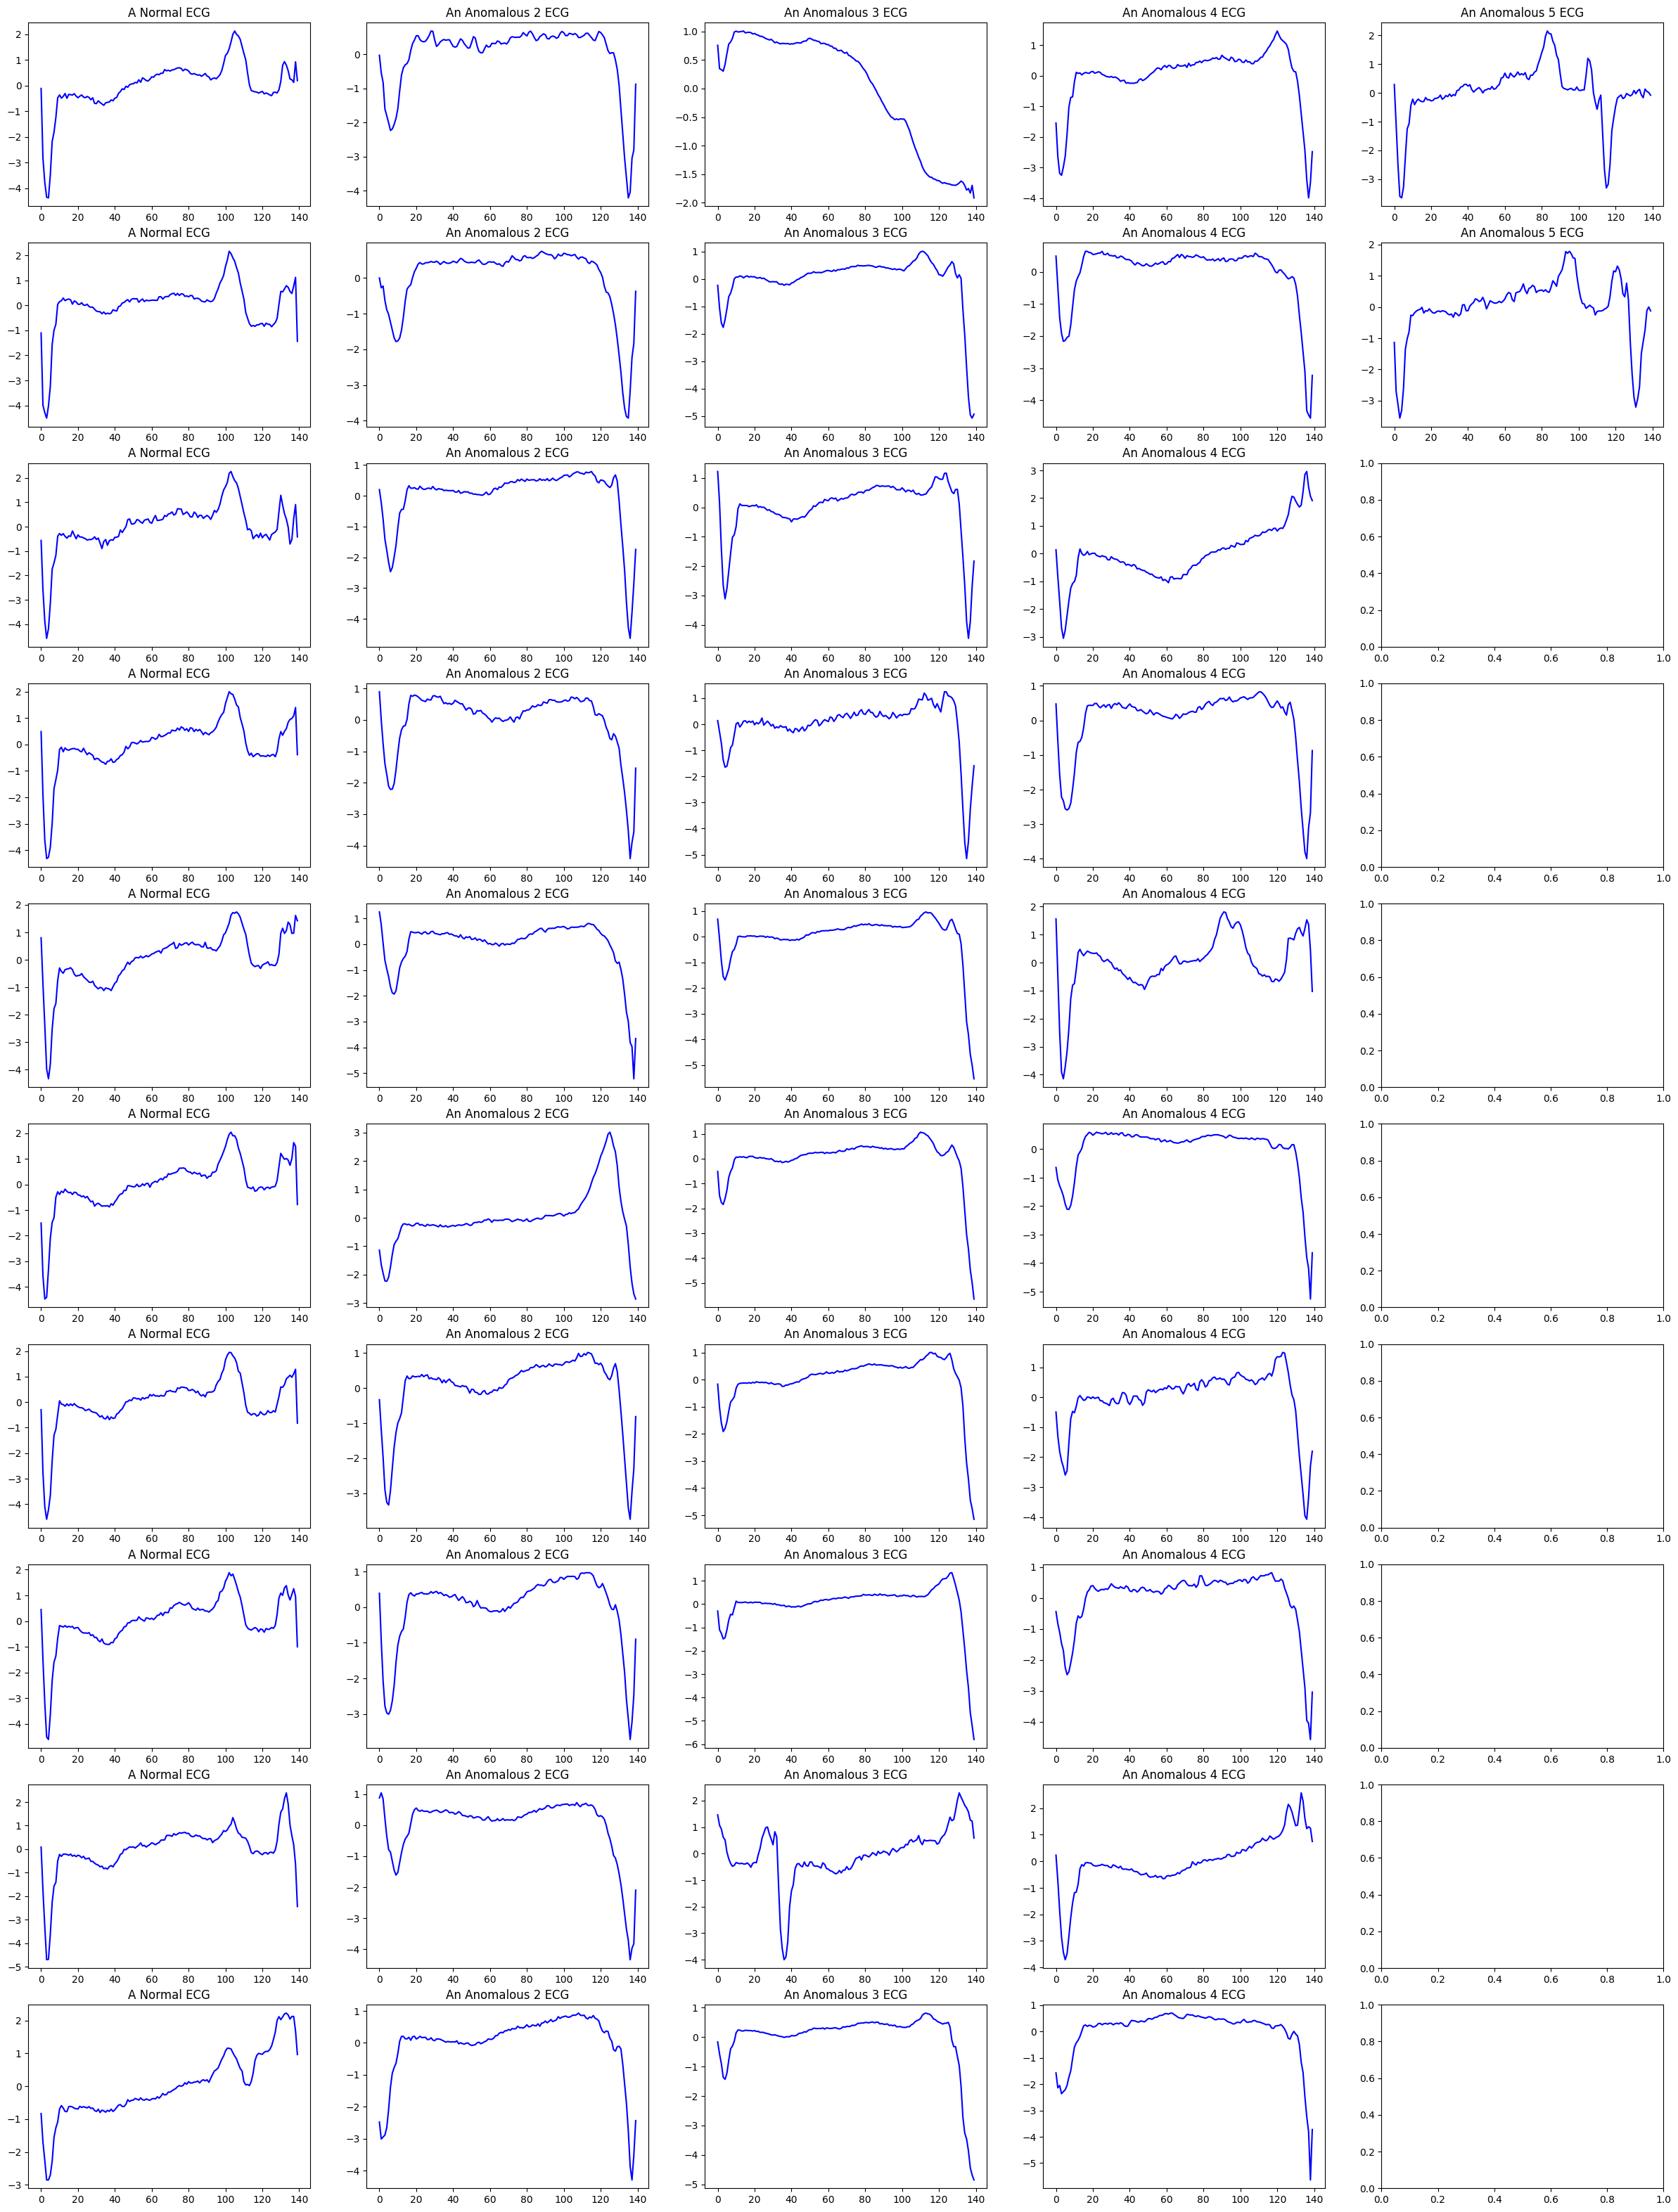

In [6]:
import matplotlib.pyplot as plt
from timeseries_autoencoder.utils import plot_reconstruction

samples = 10
fig, axes = plt.subplots(samples, 5, figsize=(30,4*samples), squeeze = False)

for s in range(samples):
    plot_reconstruction(nominal_train_data[s], axes[s][0]).set_title("A Normal ECG")
    plot_reconstruction(class_2_train_data[s], axes[s][1]).set_title("An Anomalous 2 ECG")
    plot_reconstruction(class_3_train_data[s], axes[s][2]).set_title("An Anomalous 3 ECG")
    plot_reconstruction(class_4_train_data[s], axes[s][3]).set_title("An Anomalous 4 ECG")
    if len(class_5_train_data) > s:
        plot_reconstruction(class_5_train_data[s], axes[s][4]).set_title("An Anomalous 5 ECG")


In [7]:
train_data, train_labels, test_data, test_labels = data.get_ECG5000()
nominal_train_data = train_data[train_labels == 0]
anomalous_train_data = train_data[train_labels == 1]
len(nominal_train_data), len(anomalous_train_data)


DEBUG:timeseries_autoencoder.data:creating temp file in ../data/temp/ECG5000
DEBUG:timeseries_autoencoder.data:file ../data/temp/ECG5000/ECG5000.zip already exists
DEBUG:timeseries_autoencoder.data:extracting ../data/temp/ECG5000/ECG5000.zip to ../data/temp/ECG5000
DEBUG:timeseries_autoencoder.data:reading ../data/temp/ECG5000/ECG5000_TRAIN.arff
DEBUG:timeseries_autoencoder.data:reading ../data/temp/ECG5000/ECG5000_TEST.arff
DEBUG:timeseries_autoencoder.data:modifying labels


(292, 208)

In [8]:
import pandas as pd
df = pd.DataFrame(
    data={'label': train_labels}
)
df.groupby('label').size()

label
0    292
1    208
dtype: int64

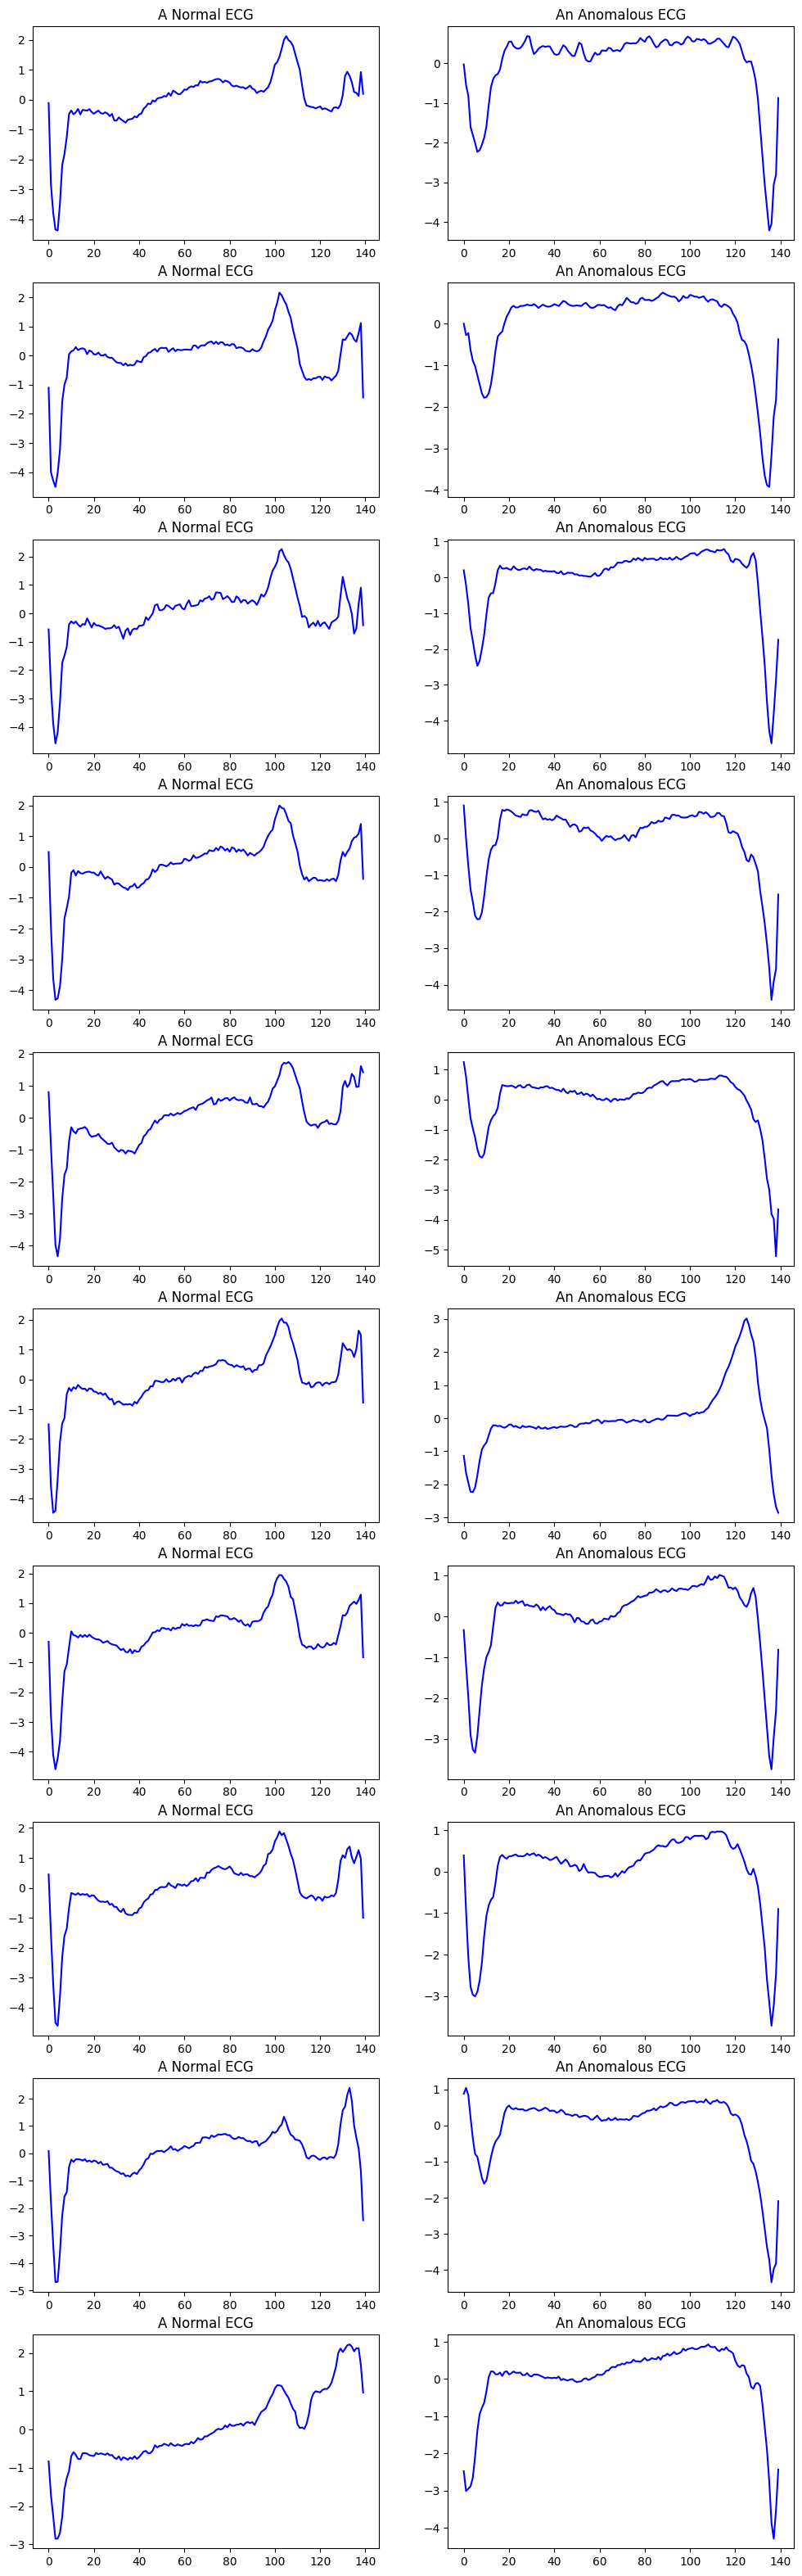

In [9]:
import matplotlib.pyplot as plt
from timeseries_autoencoder.utils import plot_reconstruction

samples = 10
fig, axes = plt.subplots(samples, 2, figsize=(12,4*samples), squeeze = False)

for s in range(samples):
    plot_reconstruction(nominal_train_data[s], axes[s][0]).set_title("A Normal ECG")
    plot_reconstruction(anomalous_train_data[s], axes[s][1]).set_title("An Anomalous ECG")